The train-test split python

Importing data and libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/regression_sprint/regression_sprint_data_1.csv', index_col=0)
df.head(10)

,ZAR/USD,Value of Exports (ZAR)
2008M01,7.01,39356.82
2008M02,7.66,46946.33
2008M03,7.97,51150.89
2008M04,7.79,56174.34
2008M05,7.62,56240.45
2008M06,7.92,60159.93
2008M07,7.63,61268.16
2008M08,7.66,60390.94
2008M09,8.06,61067.34
2008M10,9.74,65652.57


Using the train_test_split function from sklearn

In [3]:
#Import the split function from sklearn
from sklearn.model_selection import train_test_split

In [5]:
#Split the dataset into the response, y, and features, x
y = df['ZAR/USD']
X = df.drop('ZAR/USD', axis=1)


In [6]:
#Call the 'test_train_split' function:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 50)

Plotting the training and testing sets

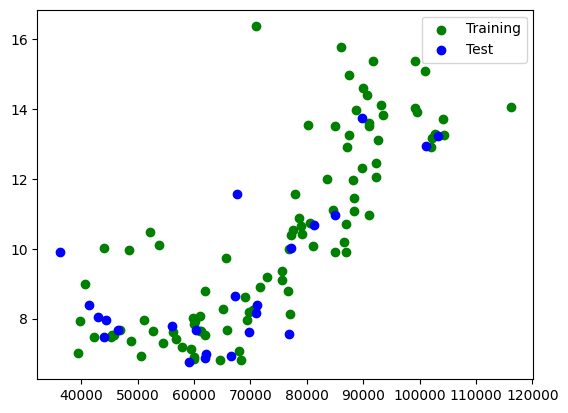

In [7]:
#PLot the splitting results
#Plot the training data in green
plt.scatter (X_train, y_train, color='green', label='Training')
#Plotting the testing data in blue
plt.scatter (X_test, y_test, color='blue', label='Test')
plt.legend()
plt.show()

Training a linear model

In [10]:
#Import the regression module
from sklearn.linear_model import LinearRegression
#Declare the model object
lm = LinearRegression()

In [11]:
#Fit the model to the training data
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
#Extract the Intercept or y-cut of our linear model
a = float(lm.intercept_)

In [13]:
#Extract the coefficient or gradient of a linear model
b = lm.coef_

In [14]:
print("Slope:\t\t", b)
print("Intercept:\t", float(a))

Slope:		 [0.0001199]
Intercept:	 1.4542630444144802


Assessing the model on the training data

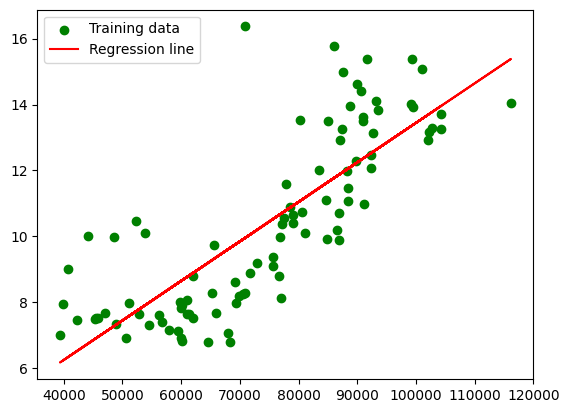

In [15]:
#Generate the values that fall along our regression line
gen_y = lm.predict(X_train)

#Plot the results
#Plot the training data in green
plt.scatter(X_train, y_train, color='green', label='Training data')
#Plot the line connecting the generated y-values
plt.plot(X_train, gen_y, color='red', label='Regression line')
plt.legend()
plt.show()

Assess the fit of the line to the training data using sklearn.metrics

In [16]:
from sklearn import metrics

In [17]:
print("Training")
#Calculate the mean-squared-error
print('MSE:', metrics.mean_squared_error(y_train, gen_y))
#Calculate the R-squared metric
print('R-squared:', metrics.r2_score(y_train, gen_y))

Training
MSE: 2.6125475375589073
R-squared: 0.6402293095045937


Assessing the model on the testing(unseen) data

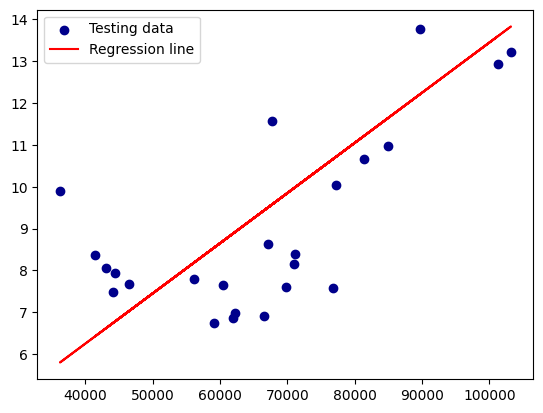

In [18]:
#Generate values of y from x, using the linear model
gen_y_test = lm.predict(X_test)

#Plot the results
#Plot the testing data in blue
plt.scatter(X_test, y_test, color='darkblue', label='Testing data')
#Plot the line connecting the generated y_values in red
plt.plot(X_test, gen_y_test, color='red', label='Regression line')
plt.legend()
plt.show()

In [19]:
print("Testing:")
print('MSE:', metrics.mean_squared_error(y_test, gen_y_test))
print('R_squared:', metrics.r2_score(y_test, gen_y_test))

Testing:
MSE: 3.038981977599916
R_squared: 0.30031043412578884
